<a href="https://colab.research.google.com/github/94Akriti/DL-ML-USING-PYTORCH/blob/main/Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pytorch - Using Torchvision for Images

Domain Libraries: based on the input file type whether it is image, video, text, audio Pytorch provide domain libraries which has dataloader functions and customizable data loading functions

In [3]:
import torch
from torch import nn

torch.__version__

'2.11.0+cu128'

In [4]:
device = "cuda" if torch.cuda.is_available() else"cpu"
device

'cuda'

## Get Data

Subset of Food101 dataset

We will work on dataset with 3 classes of food only and then gradually increase the data to 750 training 250 testing dataset

In [5]:
import requests
import zipfile
from pathlib import Path

data_path  = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists------skipping download")
else:
    print(f" {image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok = True)


with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data...")
  f.write(request.content)
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping pizza, steak, and sushi data...")
  zip_ref.extractall(image_path)

 data/pizza_steak_sushi does not exist, creating one...
Unzipping pizza, steak, and sushi data...


## Data Preparation and exploration

In [6]:
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")
walk_through_dir(image_path)


There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## Visualize the images

* Get all the image paths
* Pick random image path using Python's random.choice()
* Get image class name using pathlib.Path.parent.stem
* Using Python's PIL the images can be opened
* show images and print metadata

### Using PIL

Random Image Path: data/pizza_steak_sushi/test/sushi/3806282.jpg
 Image Class:sushi
Image size: 512
 Image width: 512


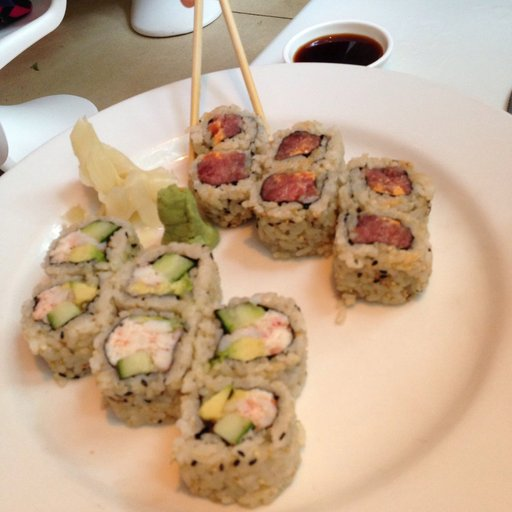

In [8]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(f"Random Image Path: {random_image_path}")

image_class = random_image_path.parent.stem
print(f" Image Class:{image_class}")

img = Image.open(random_image_path)
print(f"Image size: {img.height}")
print(f" Image width: {img.width}")
img

### Using Matplotlib

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

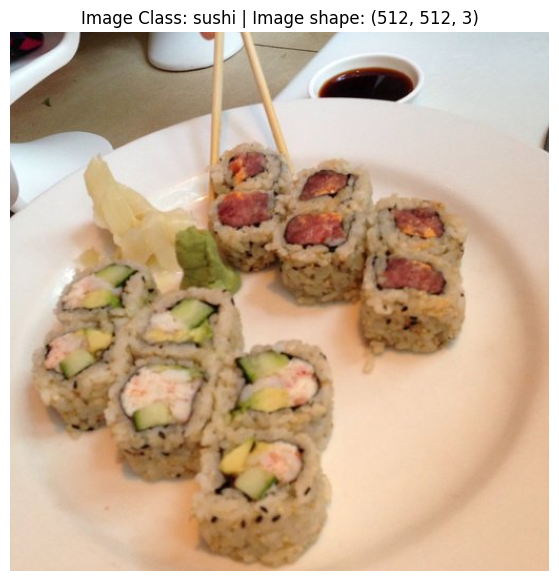

In [9]:
import numpy as np
import matplotlib.pyplot as plt

image_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image Class: {image_class} | Image shape: {image_as_array.shape}")
plt.axis(False)

array([[[  5,  14,  23],
        [  8,  12,  23],
        [ 16,   9,  25],
        ...,
        [197, 208, 212],
        [199, 210, 214],
        [200, 211, 215]],

       [[  4,  11,  21],
        [  7,  11,  22],
        [ 13,   9,  24],
        ...,
        [196, 207, 211],
        [197, 208, 212],
        [198, 209, 213]],

       [[  8,  12,  21],
        [  9,  12,  21],
        [ 12,  10,  23],
        ...,
        [196, 207, 211],
        [196, 207, 211],
        [196, 207, 211]],

       ...,

       [[229, 207, 184],
        [229, 207, 184],
        [229, 207, 184],
        ...,
        [231, 191, 156],
        [231, 191, 156],
        [231, 191, 156]],

       [[229, 207, 184],
        [229, 207, 184],
        [229, 207, 184],
        ...,
        [232, 192, 157],
        [232, 192, 157],
        [232, 192, 157]],

       [[228, 206, 183],
        [228, 206, 183],
        [228, 206, 183],
        ...,
        [232, 192, 157],
        [232, 192, 157],
        [232, 192, 157]]], dtype=uint8)
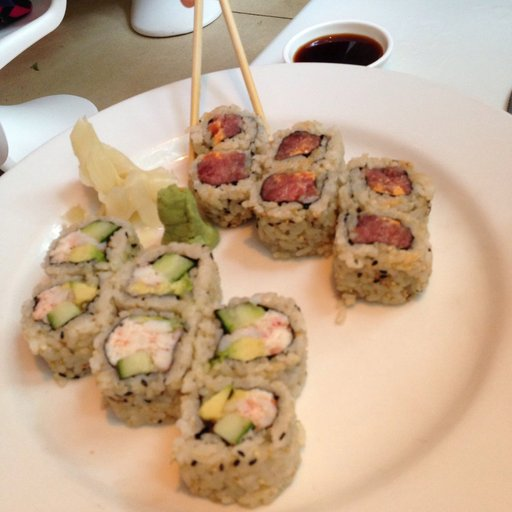

In [10]:
image_as_array

## Transforming data

To utilize image data in Pytorch models we require to follow below standard steps:

1. turn target data into tensors
2. Transform the tensors into torch.utils.data.Dataset and then torch.utils.data.DataLoader using Dataset and DataLoader.

### Transforming data using torchvision.transforms

Transforms is used to convert image data into tensors that can be readily used for our PyTorch models data augmentation

In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# convert jpeg images to tensors

data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
    ])

In [12]:
data_transform(img).shape

torch.Size([3, 64, 64])

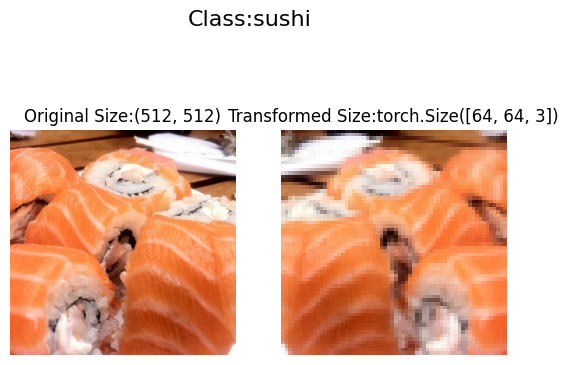

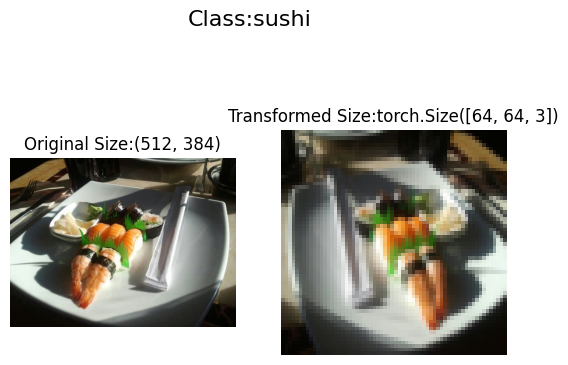

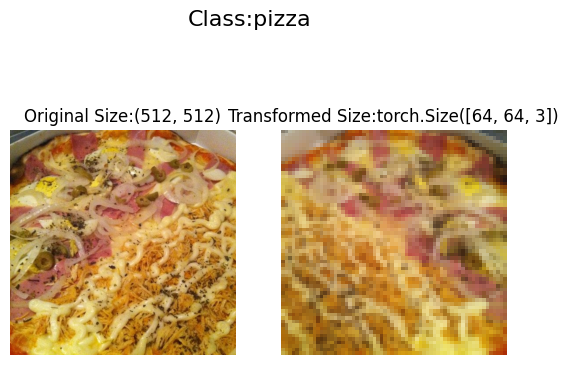

In [13]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original Size:{f.size}")
      ax[0].axis("off")
      transformed_image = transform(f).permute(1,2,0)# permute is used to change order (C,H,W)-(H,W,C) for matplotlib
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed Size:{transformed_image.shape}")
      ax[1].axis("off")
      fig.suptitle(f"Class:{image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths = image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)

## Loading images using ImageFolder



In [14]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                    transform=data_transform,
                                    target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                    transform=data_transform,
                                    target_transform=None)
print(f"Train dats:{train_data}, \nTest data:{test_data}")
print(f"Length of train data: {train_data},\n Length of Test data:{len(test_data)}")
print(f"Train directory:{train_dir} , \nTest directory: {test_dir}")

Train dats:Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ), 
Test data:Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Length of train data: Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ),
 Length of Tes

In [15]:
class_names = train_data.classes

In [16]:
class_names

['pizza', 'steak', 'sushi']

In [17]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [18]:
train_data[0]

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [19]:
img,label = train_data[0][0], train_data[0][1]
img
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Label: {label}, Class: {class_names[label]}")
print(f"Label datatype:{type(label)}")

Image tensor:
tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

In [20]:
class_names[label]

'pizza'

Original shape:torch.Size([3, 64, 64])
Image permute shape:torch.Size([64, 64, 3])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

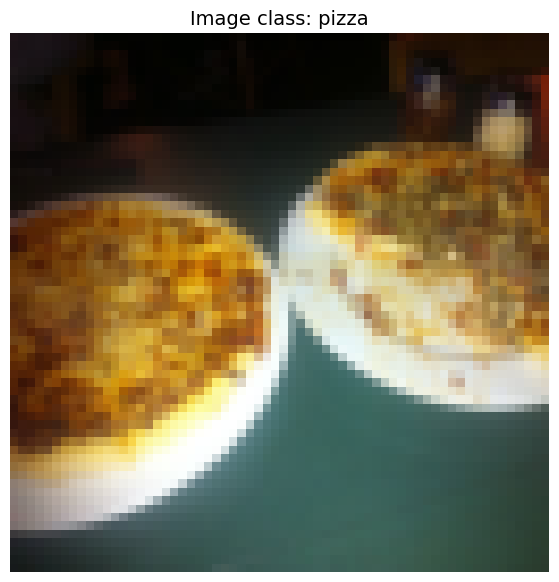

In [21]:
image_permute=  img.permute(1,2,0)

print(f"Original shape:{img.shape}")
print(f"Image permute shape:{image_permute.shape}")

plt.figure(figsize=(10,7))
plt.imshow(image_permute)
plt.title(f"Image class: {class_names[label]}",fontsize=14)
plt.axis("off")

### Turn loaded images to dataloader

DataLoader is used to convert the dataset into iterable form so it can be customized into batches

In [22]:
import os
from torch.utils.data import DataLoader
print(os.cpu_count())
BATCH_SIZE =1
train_dataloader = DataLoader(dataset = train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

print(f"Train dataloader:\n{train_dataloader}, \nTest Dataloader:\n{test_dataloader}")

2
Train dataloader:
Test Dataloader:


In [23]:
print("We have Batchsize set to 1 so both data and dataloader length will be same")
# size of the data loaded in dataloader gets divided into number of batches provided currenly 225/1 = 225
print(f"Original Train data lenght:{len(train_data)}, Train Dataloader length: {len(train_dataloader)},\nOriginal Test Data length:{len(test_data)}, Test DataLoader Length:{len(test_dataloader)}")

We have Batchsize set to 1 so both data and dataloader length will be same
Original Train data lenght:225, Train Dataloader length: 225,
Original Test Data length:75, Test DataLoader Length:75


In [24]:
img,label = next(iter(train_dataloader))

print(f"Image shape: {img.shape}")
print(f"Label shape:{label.shape}")

Image shape: torch.Size([1, 3, 64, 64])
Label shape:torch.Size([1])


# Loading image data with custom Dataset

A custom dataset can be used to load images from files, fetch class names from the dataset, get lasses in form of a dictionery from the dataset

Custom Dataset is easy to create and it is not limited to PyTorch's in-built libraries.

All custom datasets are subclass to torch.utils.data.dataset

In [25]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict, List

In [26]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Creating Helper fucntion to get class name


We will be using os.scandir() to traverse through the target file

Make error handler if the class is not found

Return class names in form of dictionary

In [27]:
target_directory = train_dir

print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
print(f"Classes Found at {target_directory}: {class_names_found}")


Target dir: data/pizza_steak_sushi/train
Classes Found at data/pizza_steak_sushi/train: ['pizza', 'steak', 'sushi']


In [28]:

def find_classes(directory: str) -> Tuple[List[str], Dict[str,int]]:
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"Couldn't find any class in {directory}")

  class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
  return classes,class_to_idx


In [29]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Custom Dataset to replicate ImageFolder

To replicate ImageFolder functionality in our custom Dataset we need to fullfill following steps:

1. subclass torch.utils.data.Dataset

2. Init our subclass with target directory then transform the data

3. Create attributes-
  path, transform, classes, class_to_id : class to index

4. Create function to load imges

5. overwrite __len()__ and __getitem()__ to return length of dataset and returning sample that is passed over an index

In [30]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):
  def __init__(self,targ_dir: str, transform=None):
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    self.transform =  transform #optional
    self.classes, self.class_to_idx = find_classes(targ_dir)

  def load_image(self,index: int) -> Image.Image:
    image_path = self.paths[index]
    return Image.open(image_path)

  # optional overwiting length
  def __len__(self) -> int:
    return len(self.paths)

  # for subclassing torch.utils.data.Dataset this is required for all custom Datasets
  def __getitem__(self,index: int) -> Tuple[torch.Tensor,int]:
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx



In [36]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()])
test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [37]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,transform=test_transforms)

In [38]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7a2180bf2060>,
 <__main__.ImageFolderCustom at 0x7a2180d48d70>)

In [39]:
len(train_data),len(train_data_custom)

(225, 225)

In [40]:
len(test_data),len(test_data_custom)

(75, 75)

In [45]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [47]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [48]:
#check for equality between custom ImageFolder and ImageFolder

print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True
